In [1]:
import torch
import numpy as np
import zipfile
from os.path import join
import pandas as pd

In [2]:
# latent_sc = np.load('latent_sc_st/latent_sc.npy')
# latent_st = np.load('latent_sc_st/latent_st.npy')

In [3]:
# # 读取encoded数据
# with zipfile.ZipFile(join(data_path, 'autoencoder_csv.zip'), 'r') as zip_ref:
#     # for name in zip_ref.namelist():
#     #     print(name)
#     with zip_ref.open('autoencoder_csv/GSE140203_mouse_skin_Gene_normalized_downsampling_encoded.csv') as file:
#         data1 = pd.read_csv(file, index_col=0)
#     with zip_ref.open('autoencoder_csv/GSE140203_mouse_skin_PeakonGene_normalized_downsampling_encoded.csv') as file:
#         data2 = pd.read_csv(file, index_col=0)
#     with zip_ref.open('autoencoder_csv/GSE140203_mouse_skin_Gene_plus_PeakonGene_normalized_downsampling_encoded.csv') as file:
#         data3 = pd.read_csv(file, index_col=0)
#     with zip_ref.open('autoencoder_csv/GSE140203_mouse_skin_Gene_times_PeakonGene_normalized_downsampling_encoded.csv') as file:
#         data4 = pd.read_csv(file, index_col=0)
# # 保存为npz文件
# np.savez(join(data_path, 'skin_normalized.npz'), gene=data1.values, peak=data2.values, gene_plus_peak=data3.values, gene_times_peak=data4.values)


In [4]:
# data_path = '/home/lqr/CLIMA/datasets/section2/processed_data'
data_path = '/home/lqr/CLIMA/datasets/new_simu/encoded'
data = np.load(join(data_path, 'skin_normalized.npz'))
for key, value in data.items():
    print(key, value.shape)
# gene_sc = torch.tensor(data['arr_0'], device='cuda:0', dtype=torch.float32).squeeze(0)
# gene_st = torch.tensor(data['arr_1'], device='cuda:0', dtype=torch.float32).squeeze(0)
gene = torch.tensor(data['gene'], device='cuda:0', dtype=torch.float32)
peak = torch.tensor(data['peak'], device='cuda:0', dtype=torch.float32)
gene_plus_peak = torch.tensor(data['gene_plus_peak'], device='cuda:0', dtype=torch.float32)
# gene_times_peak = torch.tensor(data['gene_times_peak'], device='cuda:0', dtype=torch.float32)

gene_sc = gene
gene_st = gene_plus_peak

sample_size = gene.shape[0]

gene (4531, 1024)
peak (4531, 1024)
gene_plus_peak (4531, 1024)
gene_times_peak (4531, 1024)


**************************************************
S: torch.Size([4531, 1024, 1])
G: torch.Size([4531, 1024, 1])


100%|██████████| 500/500 [00:19<00:00, 26.16it/s]


Epoch 500: Loss -1.9998133182525635
[[13.301244    4.769914    0.8811941  ... -0.91427964  2.1015873
  -1.4991591 ]
 [ 0.5855639  12.850834    0.09884396 ...  0.13718408  0.5818492
  -0.19336429]
 [-0.65959054  2.0294137  13.7871685  ...  2.5382836  -0.55782545
  -1.5208972 ]
 ...
 [-0.50407445  0.8966279   0.52030694 ... 13.106915    0.95121425
  -1.4848362 ]
 [-1.8698971  -1.1981329  -1.8038492  ...  0.12105918 12.457588
   0.15936956]
 [-0.7878109  -1.7895603  -0.8143656  ... -1.2384167   1.0196338
  13.551911  ]]


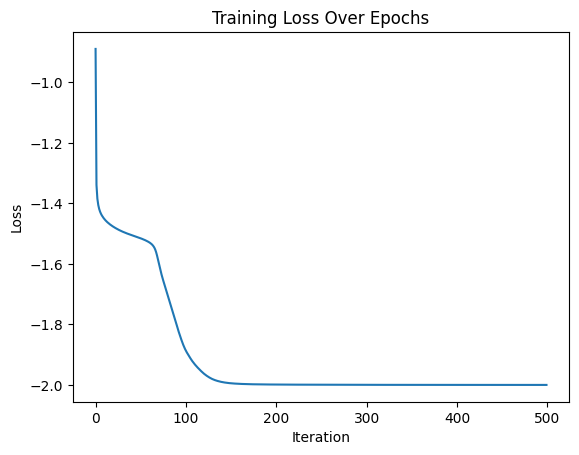

In [5]:
import sim_tangram.train_tangram as tg_cca
# tangram
cca_tg_sim, _ = tg_cca.read_csv_and_run_tangram(
    [gene_sc],
    [gene_sc],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

**************************************************
S: torch.Size([4531, 1024, 1])
G: torch.Size([4531, 1024, 1])


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:06<00:00, 78.80it/s]

Epoch 500: Loss -1.9920799732208252
[[14.902135    9.619703    1.5111177  ... -0.73263043  2.0301566
  -1.1713011 ]
 [-0.6732655   1.597538    0.0631653  ... -0.03756024  0.4406004
  -0.19308825]
 [-0.55063146  0.46772864 15.349164   ...  1.9760878  -0.4926673
  -1.0987765 ]
 ...
 [-0.07198832  0.5791049   1.1007819  ... -2.6654055   0.85247946
  -1.1533806 ]
 [-1.2832699  -0.8936445  -1.4519984  ... -0.07832089 14.568515
   0.30760938]
 [-0.78897893 -1.8337537  -1.0431467  ... -1.2912416   0.3672646
  13.340715  ]]


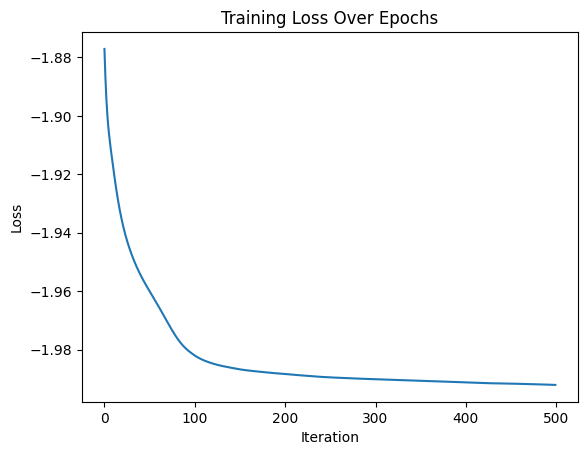

In [6]:
# 用cosine_similarity驱动的tangram进行计算

import cos_tg.train_tangram as tg_cos

# tangram
cos_tg_sim, _ = tg_cos.read_csv_and_run_tangram(
    [gene_sc],
    [gene_sc],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [7]:
torch.save(torch.tensor(cos_tg_sim, dtype=torch.float32), '/home/lqr/CLIMA/code/pretrained_weights/org_cos_tg.pt')

In [8]:
# 计算cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity
cos = cosine_similarity(gene_sc.cpu().numpy(), gene_sc.cpu().numpy())
torch.save(torch.tensor(cos, dtype=torch.float32), '/home/lqr/CLIMA/code/pretrained_weights/org_cos.pt')
cos_mapping = cos.argmax(axis=1)
for i in range(len(cos_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_mapping[i]:4d}", end="\t")
print()
print('*'*50)

# 检验cosine_similarity驱动的tangram
cos_tg_mapping = cos_tg_sim.argmax(axis=1)
for i in range(len(cos_tg_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_tg_mapping[i]:4d}", end="\t")
print()
print('*'*50)

# 检验CCA驱动的tangram
cca_tg_mapping = cca_tg_sim.argmax(axis=1)
for i in range(len(cca_tg_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cca_tg_mapping[i]:4d}", end="\t")
print()
print('*'*50)



 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	
**************************************************

 0:    0	 1:  142	 2:    2	 3:    3	 4: 2489	
 5:   97	 6: 4218	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:  145	
20:   20	21:   21	22: 3503	23:   23	24:  108	
25:   55	26:   26	27:  133	28:   28	29:   29	
**************************************************

 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	
**************************************************


In [9]:
# 计算acc
gt = np.array(range(sample_size))
cos_acc = np.sum(cos_mapping == gt) / sample_size
cos_tg_acc = np.sum(cos_tg_mapping == gt) / sample_size
tangram_acc = np.sum(cca_tg_mapping == gt) / sample_size

print("cos accuracy:", cos_acc)
print("tangram cosine accuracy:", cos_tg_acc)
print("tangram CCA accuracy:", tangram_acc)

cos accuracy: 1.0
tangram cosine accuracy: 0.6841756786581329
tangram CCA accuracy: 0.9984550871772235


In [23]:
print(np.max(cos_tg_sim[cos_tg_mapping==gt], axis=1).mean())
print(np.max(cos_tg_sim[cos_tg_mapping!=gt], axis=1).mean())


14.415675
10.763538


In [33]:
# 将相似度矩阵转换为概率分布
prob = np.exp(cos_tg_sim) / np.sum(np.exp(cos_tg_sim), axis=1, keepdims=True)
maxprob = np.max(prob, axis=1)
print(maxprob[:10])
# 计算正确和错误情况下的最大概率平均值
maxprob_correct = maxprob[cos_tg_mapping==gt]
maxprob_wrong = maxprob[cos_tg_mapping!=gt]
print(maxprob_correct.mean())
print(maxprob_wrong.mean())


[0.8959339  0.13538083 0.9374518  0.9378535  0.11690453 0.15802285
 0.0987162  0.926105   0.92867345 0.9774348 ]
0.92906487
0.16058405
